In [1]:
# first train/get a pretrianed model and covert it to an array
import torch
import numpy as np
from ultralytics import YOLO
from PIL import Image
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov5n.pt")
state_dict = model.model.state_dict()

# convert model
weights = {k.replace(".", "_"): v.cpu().numpy() for k, v in state_dict.items()}

# visualize the weights and structure
for name, array in weights.items():
    print(f"Layer: {name}")
    print(f"  Shape: {array.shape}")
    print(f"  Dtype: {array.dtype}")
    # Print first 5 elements flat
    print(f"  Sample values: {array.flatten()[:5]}")
    print("-" * 40)

/home/geeth/miniconda3/envs/yolov13/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Layer: model_0_conv_weight
  Shape: (16, 3, 6, 6)
  Dtype: float32
  Sample values: [ -0.0069771    0.041779  -0.0025826  0.00072384   0.0033131]
----------------------------------------
Layer: model_0_bn_weight
  Shape: (16,)
  Dtype: float32
  Sample values: [     1.9062      2.0273      5.5508       1.041      3.7422]
----------------------------------------
Layer: model_0_bn_bias
  Shape: (16,)
  Dtype: float32
  Sample values: [     1.5957      1.5889      -6.457      4.3125     -5.7539]
----------------------------------------
Layer: model_0_bn_running_mean
  Shape: (16,)
  Dtype: float32
  Sample values: [  -0.019547  -0.0048332    -0.4

## Inference >>>

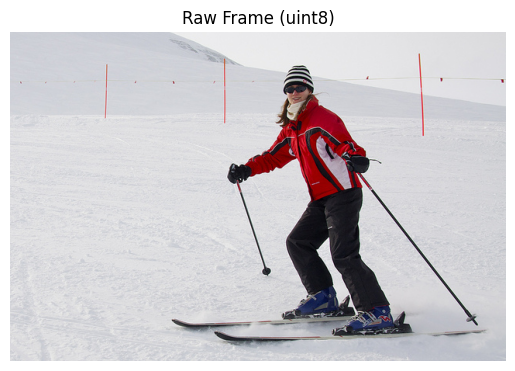

In [2]:
weights = weights
frame = Image.open("/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000785.jpg")
frame = np.array(frame)

# visualize
plt.imshow(frame)  # HWC, RGB
plt.title("Raw Frame (uint8)")
plt.axis("off")
plt.show()

### 1. Pre process img/vid (frame)

  Shape: (3, 640, 640)
  Dtype: float32


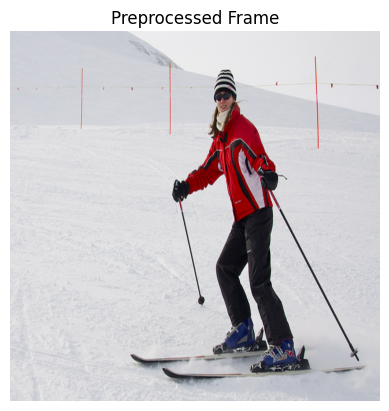

In [3]:
# 1.1. downscale
res = "640*640" #320*320

if res == "320*320":
    imsz = (640,640)
else:   # default
    imsz = (640,640)

frame = cv2.resize(frame, imsz)

# 1.2. convert frame to np.arrays unit8->float32,float16,int8
d_type = "fp32"

if d_type == "fp16":
    frame = frame.astype(np.float16)
elif d_type == "int8":
    frame = (frame*255).astype(np.int8)
else: # default
    frame = frame.astype(np.float32)

# 1.3. Normalize to [0,1]
frame = frame/255

# 1.4 Convert from HWC to CHW
frame = np.transpose(frame, (2, 0, 1))

# visualize (convert back to HWC)
print(f"  Shape: {frame.shape}")
print(f"  Dtype: {frame.dtype}")
frame_to_show = frame.transpose(1, 2, 0)
plt.imshow(frame_to_show)
plt.title("Preprocessed Frame")
plt.axis("off")
plt.show()

In [ ]:
# # Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# # Parameters
# nc: 80 # number of classes
# depth_multiple: 0.33 # model depth multiple
# width_multiple: 0.25 # layer channel multiple
# anchors:
#   - [10, 13, 16, 30, 33, 23] # P3/8
#   - [30, 61, 62, 45, 59, 119] # P4/16
#   - [116, 90, 156, 198, 373, 326] # P5/32

# # YOLOv5 v6.0 backbone
# backbone:
#   # [from, number, module, args]
#   [
#     [-1, 1, Conv, [64, 6, 2, 2]], # 0-P1/2
#     [-1, 1, Conv, [128, 3, 2]], # 1-P2/4
#     [-1, 3, C3, [128]],
#     [-1, 1, Conv, [256, 3, 2]], # 3-P3/8
#     [-1, 6, C3, [256]],
#     [-1, 1, Conv, [512, 3, 2]], # 5-P4/16
#     [-1, 9, C3, [512]],
#     [-1, 1, Conv, [1024, 3, 2]], # 7-P5/32
#     [-1, 3, C3, [1024]],
#     [-1, 1, SPPF, [1024, 5]], # 9
#   ]

# # YOLOv5 v6.0 head
# head: [
#     [-1, 1, Conv, [512, 1, 1]],
#     [-1, 1, nn.Upsample, [None, 2, "nearest"]],
#     [[-1, 6], 1, Concat, [1]], # cat backbone P4
#     [-1, 3, C3, [512, False]], # 13

#     [-1, 1, Conv, [256, 1, 1]],
#     [-1, 1, nn.Upsample, [None, 2, "nearest"]],
#     [[-1, 4], 1, Concat, [1]], # cat backbone P3
#     [-1, 3, C3, [256, False]], # 17 (P3/8-small)

#     [-1, 1, Conv, [256, 3, 2]],
#     [[-1, 14], 1, Concat, [1]], # cat head P4
#     [-1, 3, C3, [512, False]], # 20 (P4/16-medium)

#     [-1, 1, Conv, [512, 3, 2]],
#     [[-1, 10], 1, Concat, [1]], # cat head P5
#     [-1, 3, C3, [1024, False]], # 23 (P5/32-large)

#     [[17, 20, 23], 1, Detect, [nc, anchors]], # Detect(P3, P4, P5)
#   ]

### 2. Forward Pass

for each layer
1. conv
2. batch norm
3. SiLU activation

In [4]:
import numpy as np
from scipy.signal import correlate

# ----------------------------
# SiLU activation
# ----------------------------
def SiLU(x):
    return x / (1 + np.exp(-x))  # x * sigmoid(x)

# ----------------------------
# Conv2D without BN
# ----------------------------
def Conv2d(x, weight, bias=None, stride=1, padding=0, dilation=1, groups=1):
    """
    x: input image of shape (N, C_in, H, W)
    weight: conv weights (C_out, C_in/groups, kH, kW)
    bias: optional bias (C_out,)
    """
    N, C_in, H, W = x.shape
    C_out, _, kH, kW = weight.shape

    # Add padding
    if padding > 0:
        x_padded = np.pad(x, ((0,0),(0,0),(padding,padding),(padding,padding)), mode='constant')
    else:
        x_padded = x

    H_out = (H + 2*padding - dilation*(kH-1) - 1)//stride + 1
    W_out = (W + 2*padding - dilation*(kW-1) - 1)//stride + 1

    y = np.zeros((N, C_out, H_out, W_out), dtype=np.float32)

    # Loop over batch
    for n in range(N):
        for co in range(C_out):
            for ci in range(C_in):
                y[n, co] += correlate(x_padded[n, ci], weight[co, ci], mode='valid')[::stride, ::stride]
            if bias is not None:
                y[n, co] += bias[co]
    return y

# ----------------------------
# Conv2D + BN + SiLU
# ----------------------------
def ConvBNSiLU(x, conv_w, conv_b, bn_w, bn_b, bn_rm, bn_rv, stride=1, padding=0, epsilon=1e-5):
    # Conv
    x = Conv2d(x, conv_w, conv_b, stride=stride, padding=padding)
    # BatchNorm
    x = bn_w.reshape(1,-1,1,1) * (x - bn_rm.reshape(1,-1,1,1)) / np.sqrt(bn_rv.reshape(1,-1,1,1) + epsilon) + bn_b.reshape(1,-1,1,1)
    # Activation
    return SiLU(x)

# ----------------------------
# Bottleneck: Conv-BN-SiLU -> Conv-BN-SiLU + optional residual
# ----------------------------
def Bottleneck(x, cv1_w, cv1_b, cv1_bn_w, cv1_bn_b, cv1_rm, cv1_rv,
                     cv2_w, cv2_b, cv2_bn_w, cv2_bn_b, cv2_rm, cv2_rv,
                     shortcut=True, epsilon=1e-5):
    y = ConvBNSiLU(x, cv1_w, cv1_b, cv1_bn_w, cv1_bn_b, cv1_rm, cv1_rv)
    y = ConvBNSiLU(y, cv2_w, cv2_b, cv2_bn_w, cv2_bn_b, cv2_rm, cv2_rv)
    if shortcut and x.shape == y.shape:
        y = y + x
    return y

# ----------------------------
# Concat along channel dim
# ----------------------------
def Concat(tensors, dim=1):
    return np.concatenate(tensors, axis=dim)

# ----------------------------
# MaxPool2D
# ----------------------------
def Maxpool2D(x, kernel_size=2, stride=2):
    N, C, H, W = x.shape
    H_out = (H - kernel_size)//stride + 1
    W_out = (W - kernel_size)//stride + 1
    y = np.zeros((N, C, H_out, W_out), dtype=x.dtype)
    for i in range(H_out):
        for j in range(W_out):
            y[:,:,i,j] = np.max(x[:,:,i*stride:i*stride+kernel_size,j*stride:j*stride+kernel_size], axis=(2,3))
    return y

# ----------------------------
# Upsample
# ----------------------------
def Upsample(x, scale_factor=2):
    N, C, H, W = x.shape
    return np.repeat(np.repeat(x, scale_factor, axis=2), scale_factor, axis=3)

In [6]:
depth_multiple= 0.33 # model depth multiple
width_multiple= 0.25 # layer channel multiple

Layer definition: [-1, 1, 'Conv', [64, 6, 2, 2]]
From: -1
Repeat (depth scaled): 1
Kernel: 6
Stride: 2
Padding: 2
Channels original: 64
Channels scaled: 16

Input layer: 0
Shape: (1, 3, 640, 640)
Dtype: float32

Output layer: 0
Shape: (1, 16, 320, 320)
Expected channels: 16
Dtype: float32

Expected job: detect edges, color grads, texture primitives, corners


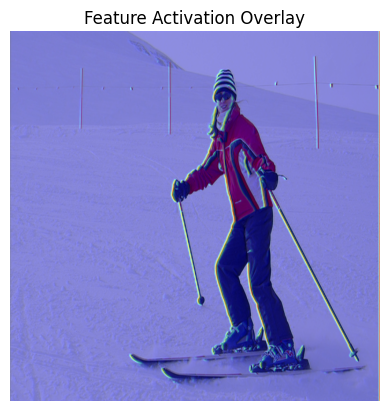

In [9]:
layer_def = [-1, 1, "Conv", [64, 6, 2, 2]]  # [from, number, module, args]
from_idx, number, _, args = layer_def
out_channels, kernel, stride, padding = args

repeat = max(round(number * depth_multiple), 1)
scaled_channels = int(out_channels * width_multiple)

print("Layer definition:", layer_def)
print("From:", from_idx)
print("Repeat (depth scaled):", repeat)
print("Kernel:", kernel)
print("Stride:", stride)
print("Padding:", padding)
print("Channels original:", out_channels)
print("Channels scaled:", scaled_channels)

# ----------------------------
# Input layer
# ----------------------------
layer = 0
job = "detect edges, color grads, texture primitives, corners"

layer0_in = layer0_in = np.expand_dims(frame, axis=0)
print(f"\nInput layer: {layer}")
print(f"Shape: {layer0_in.shape}")
print(f"Dtype: {layer0_in.dtype}")

# ----------------------------
# Assign weights (NumPy arrays from YOLO)
# ----------------------------
conv_w   = weights["model_0_conv_weight"].astype(np.float32)      # (C_out, C_in, kH, kW)
conv_b   = None
bn_gamma = weights["model_0_bn_weight"].astype(np.float32)        # (C_out,)
bn_beta  = weights["model_0_bn_bias"].astype(np.float32)          # (C_out,)
bn_mean  = weights["model_0_bn_running_mean"].astype(np.float32)  # (C_out,)
bn_var   = weights["model_0_bn_running_var"].astype(np.float32)   # (C_out,)

# ----------------------------
# Forward pass using ConvBNSiLU
# ----------------------------
layer0_out = ConvBNSiLU(
    layer0_in,
    conv_w=conv_w,
    conv_b=conv_b,        # Conv2d bias=False like YOLO
    bn_w=bn_gamma,
    bn_b=bn_beta,
    bn_rm=bn_mean,
    bn_rv=bn_var,
    stride=stride,
    padding=padding
)

print(f"\nOutput layer: {layer}")
print(f"Shape: {layer0_out.shape}")
print(f"Expected channels: {scaled_channels}")
print(f"Dtype: {layer0_out.dtype}")
print("\nExpected job:", job)

# ----------------------------
# Visualize first feature map
# ----------------------------
# take first feature map of batch
heatmap = layer0_out[0,0]  # first channel
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
heatmap = cv2.resize(heatmap, (640,640))

plt.imshow(frame_to_show)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title("Feature Activation Overlay")
plt.show()

Layer definition: [-1, 1, 'Conv', [128, 3, 2, 1]]
From: -1
Repeat (depth scaled): 1
Kernel: 3
Stride: 2
Padding: 1
Channels original: 128
Channels scaled: 32

Input layer: 1
Shape: (1, 16, 320, 320)
Dtype: float32

Output layer: 1
Shape: (1, 32, 160, 160)
Expected channels: 32
Dtype: float32

Expected job: downsample, feature extraction, preparing for deeper layers


/tmp/ipykernel_19239/2780927046.py:8: RuntimeWarning: overflow encountered in exp
  return x / (1 + np.exp(-x))  # x * sigmoid(x)


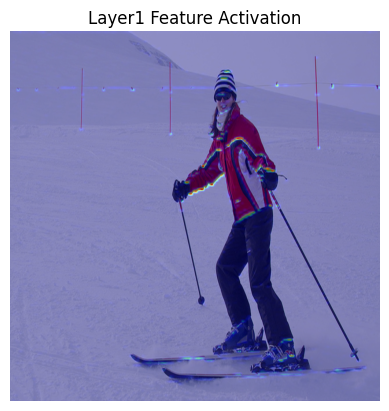

In [12]:
# [from, number, module, args]
layer_def = [-1, 1, "Conv", [128, 3, 2, 1]]

from_idx, number, _, args = layer_def
out_channels, kernel, stride, padding = args
repeat = max(round(number * depth_multiple), 1)
scaled_channels = int(out_channels * width_multiple)

print("Layer definition:", layer_def)
print("From:", from_idx)
print("Repeat (depth scaled):", repeat)
print("Kernel:", kernel)
print("Stride:", stride)
print("Padding:", padding)
print("Channels original:", out_channels)
print("Channels scaled:", scaled_channels)

# ----------------------------
# Layer1
# ----------------------------
job = "downsample, feature extraction, preparing for deeper layers"
layer = 1

# input (already NCHW)
layer1_in = layer0_out.astype(np.float32)

print(f"\nInput layer: {layer}")
print(f"Shape: {layer1_in.shape}")
print(f"Dtype: {layer1_in.dtype}")

# ----------------------------
# weights
# ----------------------------
conv_w   = weights["model_1_conv_weight"].astype(np.float32)

conv_b = None  # YOLO Conv uses bias=False

bn_gamma = weights["model_1_bn_weight"].astype(np.float32)
bn_beta  = weights["model_1_bn_bias"].astype(np.float32)
bn_mean  = weights["model_1_bn_running_mean"].astype(np.float32)
bn_var   = weights["model_1_bn_running_var"].astype(np.float32)

# ----------------------------
# forward
# ----------------------------
layer1_out = ConvBNSiLU(
    layer1_in,
    conv_w=conv_w,
    conv_b=conv_b,
    bn_w=bn_gamma,
    bn_b=bn_beta,
    bn_rm=bn_mean,
    bn_rv=bn_var,
    stride=stride,
    padding=padding
)

print(f"\nOutput layer: {layer}")
print(f"Shape: {layer1_out.shape}")
print(f"Expected channels: {scaled_channels}")
print(f"Dtype: {layer1_out.dtype}")

print("\nExpected job:", job)

# ----------------------------
# visualize feature map
# ----------------------------
heatmap = layer1_out[0, 0]   # batch 0, channel 0

heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-6)
heatmap = cv2.resize(heatmap, (640,640))

plt.imshow(frame_to_show)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title("Layer1 Feature Activation")
plt.show()